# SentinelMail — RoBERTa Fine-Tuned: Training & Evaluation

Fine-tunes `roberta-base` on the ai4privacy training split and evaluates it on the
validation split. Saves metrics to `evaluation/results/roberta_metrics.json` for ensemble comparison.

**Prerequisites**
- `pip install transformers torch`
- HuggingFace model weights downloaded automatically on first run

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

CHECKPOINT_DIR = REPO_ROOT / "models" / "roberta" / "checkpoint"
RESULTS_DIR    = REPO_ROOT / "evaluation" / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

/Users/erelv/projects-chkp/final-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
from data.preprocessing import load_split, LABEL_COLS
from models.roberta.dataset import DLPDataset, collate_fn
from models.roberta.model   import RobertaForDLPClassification
from models.roberta.predict import RobertaDLPDetector
from evaluation import (
    compute_all_metrics,
    classify_errors,
    error_summary,
    plot_confusion_matrices,
    plot_per_label_bars,
    plot_roc_curves,
    plot_pr_curves,
    save_results,
    from_dataframe,
    LABEL_COLS,
)

## 1. Load Data

In [3]:
print("Loading splits...")
train_df = load_split("train")
val_df   = load_split("validation")

train_texts  = train_df["source_text"].tolist()
val_texts    = val_df["source_text"].tolist()
train_labels = train_df[LABEL_COLS].values.astype(np.float32)
val_labels   = val_df[LABEL_COLS].values.astype(np.float32)

print(f"Train: {len(train_texts):,} samples")
print(f"Val:   {len(val_texts):,} samples")
print()
print("Label distribution (train):")
print(train_df[LABEL_COLS].sum().to_string())

Loading splits...


Train: 29,908 samples
Val:   7,946 samples

Label distribution (train):
benign           3482
PII             26426
financial        5688
confidential    13252


## 2. Encode Inputs

In [4]:
MODEL_NAME = "roberta-base"
BATCH_SIZE = 16

print(f"Loading {MODEL_NAME} encoder...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = DLPDataset(train_texts, train_labels, tokenizer)
val_ds   = DLPDataset(val_texts,   val_labels,   tokenizer)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
)

print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}")

Loading roberta-base encoder...
Train batches: 1,870  |  Val batches: 497


## 3. Initialise Model

In [5]:
model = RobertaForDLPClassification().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}  (blocks 10-11 + head)")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9476.10it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     124,648,708
Trainable params: 14,769,412  (blocks 10-11 + head)


## 4. Train

Skip this cell if `checkpoint/best_model.pt` already exists — section 5 loads it.

Early stopping on **val macro-F1** (not val loss).

In [6]:
EPOCHS           = 5
LR               = 2e-5
LABEL_SMOOTHING  = 0.05
WARMUP_FRACTION  = 0.10
CKPT             = CHECKPOINT_DIR / "best_model.pt"


def _pos_weights(labels: np.ndarray, device: torch.device) -> torch.Tensor:
    pos = labels.sum(axis=0).clip(1)
    neg = len(labels) - pos
    return torch.tensor(neg / pos, dtype=torch.float32).to(device)


def _smooth(labels: torch.Tensor, eps: float = LABEL_SMOOTHING) -> torch.Tensor:
    return labels * (1.0 - eps) + (1.0 - labels) * eps


def _macro_f1_from_logits(logits_list, labels_list) -> float:
    proba  = torch.sigmoid(torch.cat(logits_list)).cpu().numpy()
    y_pred = (proba >= 0.5).astype(int)
    y_true = torch.cat(labels_list).cpu().numpy().astype(int)
    f1s = []
    for i in range(4):
        tp = ((y_pred[:, i] == 1) & (y_true[:, i] == 1)).sum()
        fp = ((y_pred[:, i] == 1) & (y_true[:, i] == 0)).sum()
        fn = ((y_pred[:, i] == 0) & (y_true[:, i] == 1)).sum()
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1s.append(2 * p * r / (p + r) if (p + r) > 0 else 0.0)
    return float(np.mean(f1s))


criterion = nn.BCEWithLogitsLoss(pos_weight=_pos_weights(train_labels, DEVICE))
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=0.01
)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_FRACTION * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for input_ids, attention_mask, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        input_ids, attention_mask, labels = (
            input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)
        )
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, _smooth(labels))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    val_logits_all, val_labels_all = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids, attention_mask, labels_dev = (
                input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)
            )
            logits    = model(input_ids, attention_mask)
            val_loss += criterion(logits, _smooth(labels_dev)).item()
            val_logits_all.append(logits.detach())
            val_labels_all.append(labels)

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    val_f1    = _macro_f1_from_logits(val_logits_all, val_labels_all)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_f1"].append(val_f1)

    marker = "  ✓ saved" if val_f1 > best_val_f1 else ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT)
    print(f"Epoch {epoch:02d}/{EPOCHS}  train={avg_train:.4f}  val={avg_val:.4f}  macro-F1={val_f1:.4f}{marker}")

print(f"\nBest val macro-F1: {best_val_f1:.4f}  →  {CKPT}")

Epoch 01/5  train=0.5973  val=0.4629  macro-F1=0.8984  ✓ saved


Epoch 02/5  train=0.4565  val=0.4473  macro-F1=0.9474  ✓ saved


Epoch 03/5  train=0.4438  val=0.4424  macro-F1=0.9542  ✓ saved


Epoch 04/5  train=0.4360  val=0.4427  macro-F1=0.9591  ✓ saved


Epoch 05/5  train=0.4323  val=0.4406  macro-F1=0.9570

Best val macro-F1: 0.9591  →  /Users/erelv/projects-chkp/final-project/models/roberta/checkpoint/best_model.pt


### 4a. Learning Curves

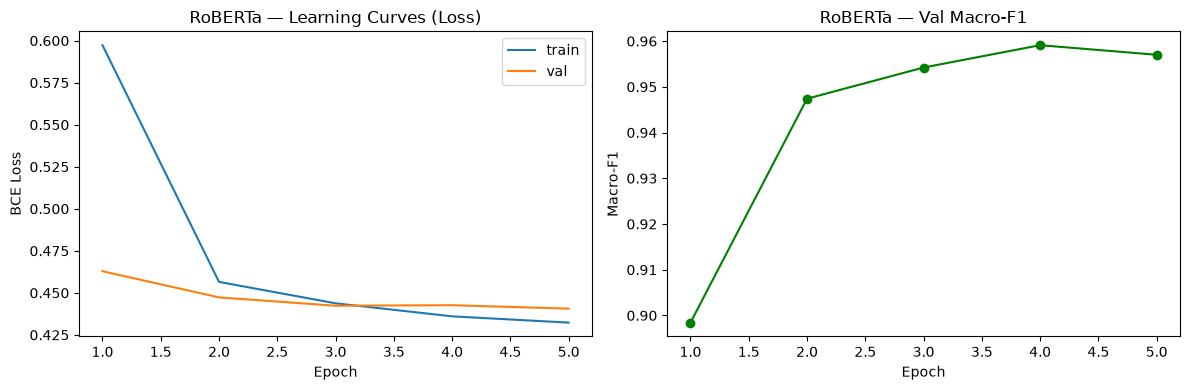

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"],   label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("RoBERTa — Learning Curves (Loss)")
axes[0].legend()

axes[1].plot(epochs_range, history["val_f1"], color="green", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro-F1")
axes[1].set_title("RoBERTa — Val Macro-F1")

plt.tight_layout()
plt.show()

## 5. Load Best Checkpoint

In [8]:
CKPT = CHECKPOINT_DIR / "best_model.pt"

detector = RobertaDLPDetector(
    checkpoint_path=str(CKPT),
    device=str(DEVICE),
)
print(f"Loaded: {CKPT.name}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 15364.04it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: best_model.pt


## 6. Run Inference on Validation Set

In [9]:
THRESHOLD = 0.5

print(f"Running predict_proba on {len(val_texts):,} samples...")
y_proba = detector.predict_proba(val_texts)       # (N, 4) float32
y_pred  = (y_proba >= THRESHOLD).astype(np.int32) # (N, 4) int
y_true  = from_dataframe(val_df)                   # (N, 4) int

print(f"y_proba range: [{y_proba.min():.3f}, {y_proba.max():.3f}]")
print()
print(f"{'label':14s}  {'pred':>6s}  {'true':>6s}")
for i, col in enumerate(LABEL_COLS):
    print(f"  {col:12s}  {y_pred[:,i].sum():6d}  {y_true[:,i].sum():6d}")

Running predict_proba on 7,946 samples...
y_proba range: [0.003, 0.998]

label             pred    true
  benign           958     908
  PII             6974    7038
  financial       1540    1529
  confidential    3749    3632


## 7. Metrics

In [10]:
metrics = compute_all_metrics(y_true, y_pred, y_proba=y_proba)

ci = metrics["macro_f1_ci"]
print(f"Macro-F1:      {metrics['macro_f1']:.4f}  "
      f"(95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}])")
print(f"Macro AUC-ROC: {metrics['auc_roc']['macro']:.4f}")
print()

pd.DataFrame(metrics["per_label"]).T.round(4)

Macro-F1:      0.9591  (95% CI: [0.9548, 0.9634])
Macro AUC-ROC: 0.9910



,precision,recall,f1,support
benign,0.9019,0.9515,0.9260,908.0
PII,0.9944,0.9854,0.9899,7038.0
financial,0.9422,0.9490,0.9456,1529.0
confidential,0.9597,0.9906,0.9749,3632.0


### 7a. Threshold Sensitivity (0.3 / 0.5 / 0.7)

In [11]:
rows = []
for t in [0.3, 0.5, 0.7]:
    m   = compute_all_metrics(y_true, (y_proba >= t).astype(np.int32), n_bootstrap=50)
    row = {"threshold": t, "macro_f1": round(m["macro_f1"], 4)}
    for label in LABEL_COLS:
        row[f"{label}_f1"] = round(m["per_label"][label]["f1"], 4)
    rows.append(row)

pd.DataFrame(rows).set_index("threshold")

,macro_f1,benign_f1,PII_f1,financial_f1,confidential_f1
threshold,,,,,
0.3,0.8746,0.6573,0.9909,0.8814,0.9686
0.5,0.9591,0.9260,0.9899,0.9456,0.9749
0.7,0.9516,0.9324,0.9455,0.9504,0.9783


## 8. Confusion Matrices & Per-Label Bars

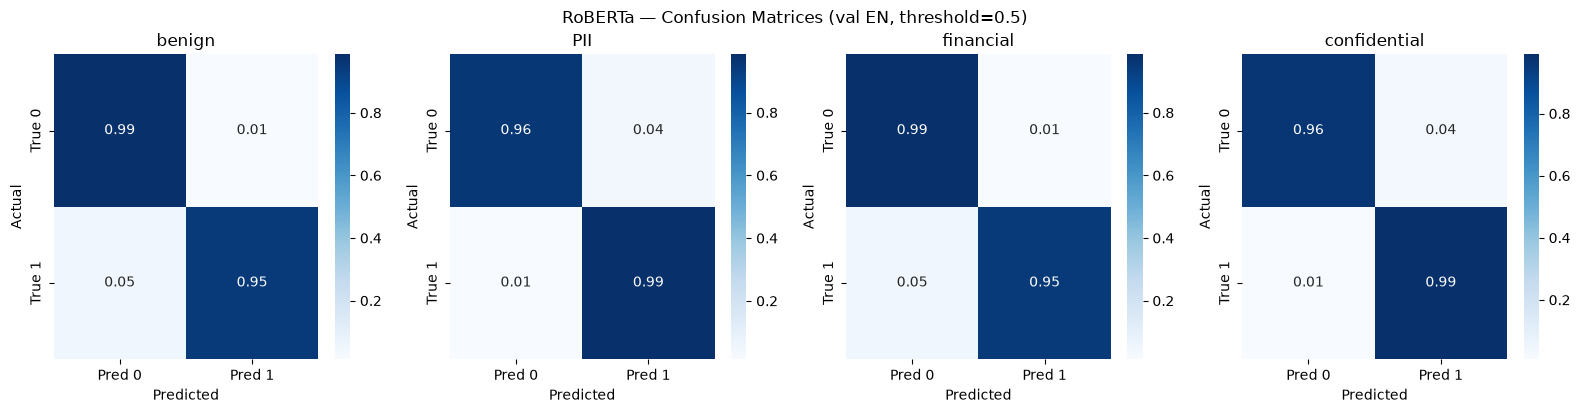

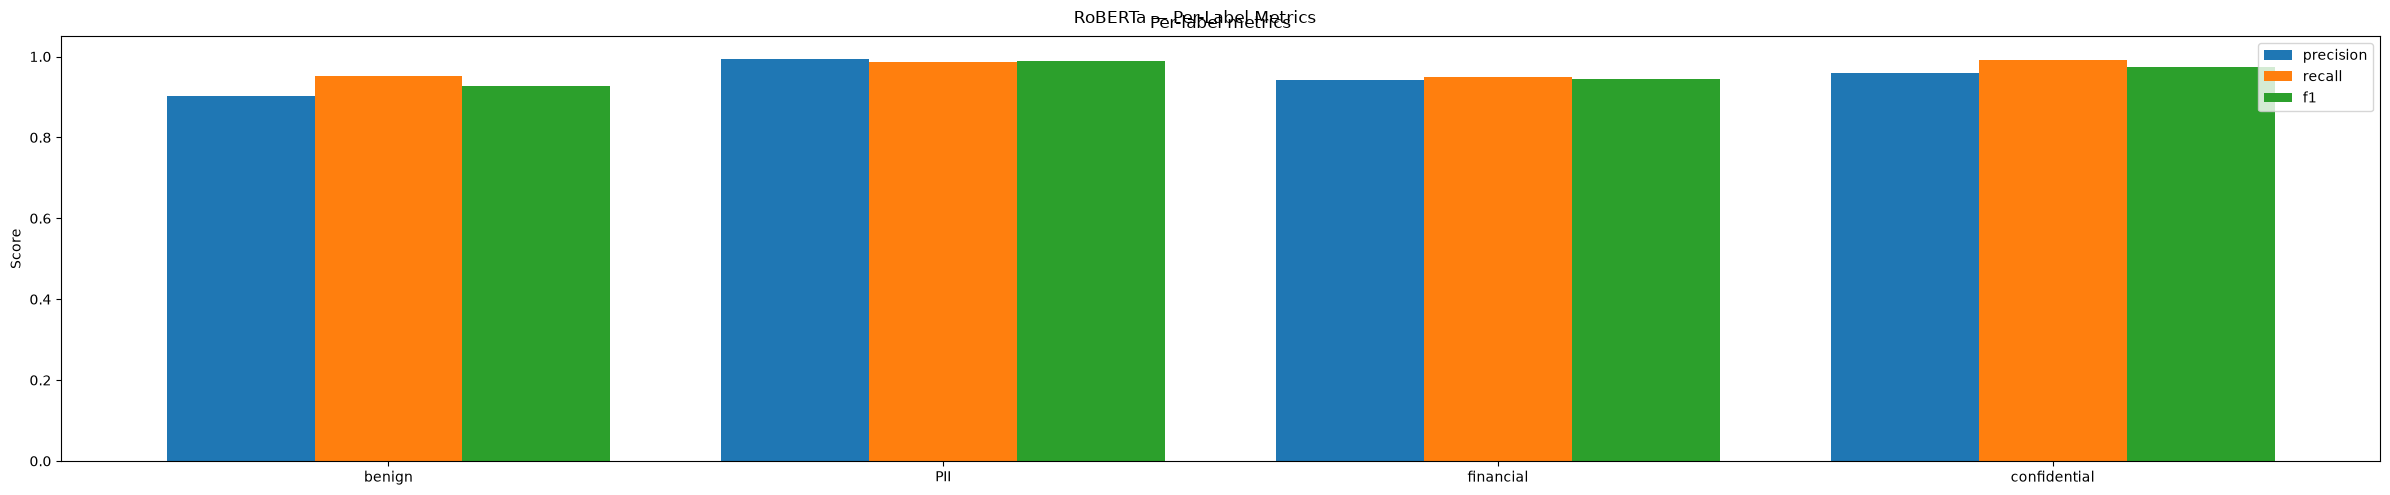

In [12]:
_, fig = plot_confusion_matrices(y_true, y_pred, normalize="true", return_fig=True)
fig.suptitle("RoBERTa — Confusion Matrices (val EN, threshold=0.5)", y=1.02)
plt.show()

_, bar_fig = plot_per_label_bars(metrics, return_fig=True)
bar_fig.suptitle("RoBERTa — Per-Label Metrics")
plt.show()

## 9. ROC & PR Curves

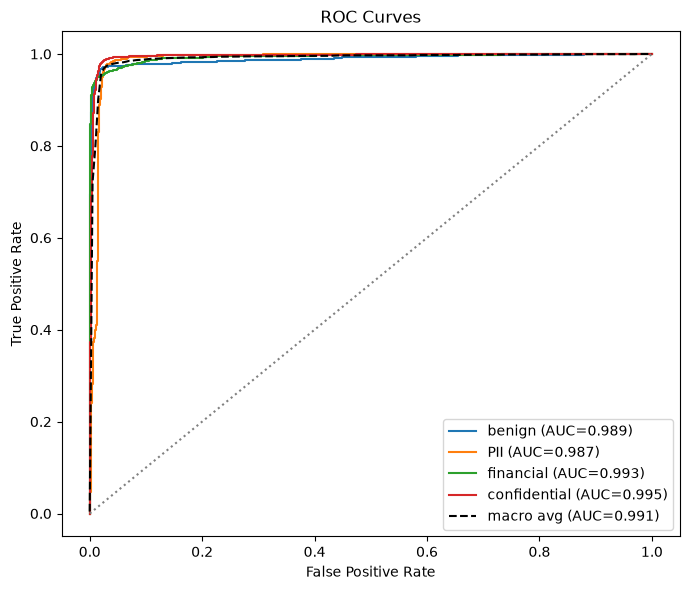

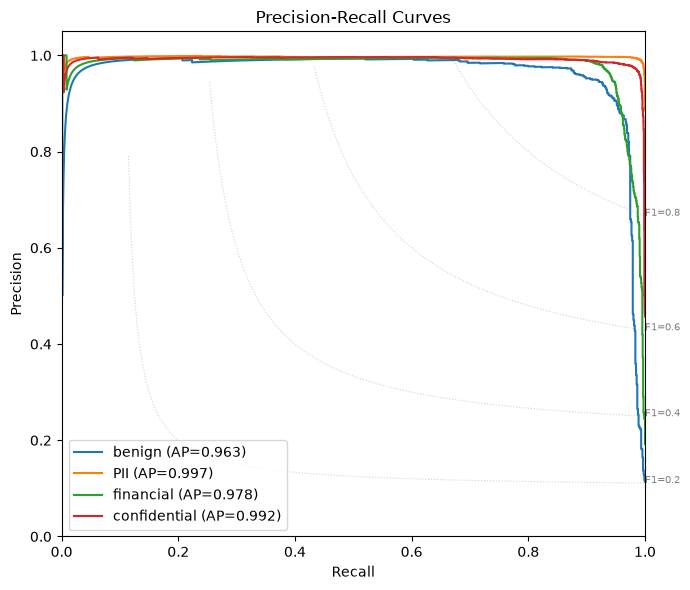

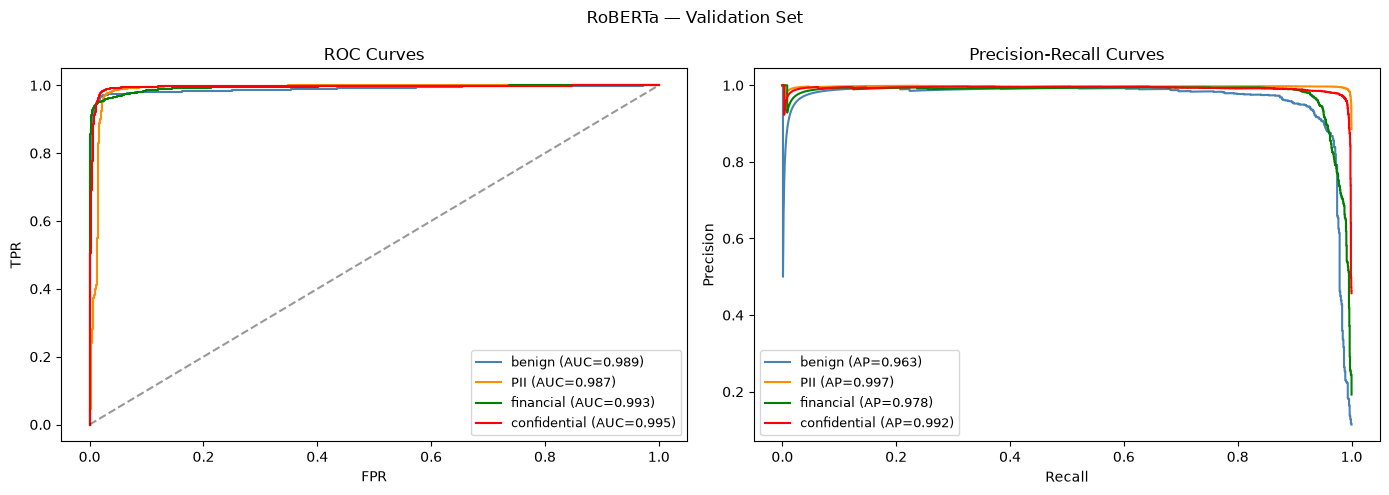

In [13]:
roc_data = plot_roc_curves(y_true, y_proba)
pr_data  = plot_pr_curves(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ["steelblue", "darkorange", "green", "red"]

for i, label in enumerate(LABEL_COLS):
    axes[0].plot(roc_data[label]["fpr"], roc_data[label]["tpr"],
                 label=f"{label} (AUC={roc_data[label]['auc']:.3f})", color=COLORS[i])
    axes[1].plot(pr_data[label]["recall"], pr_data[label]["precision"],
                 label=f"{label} (AP={pr_data[label]['ap']:.3f})", color=COLORS[i])

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=9)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=9)
fig.suptitle("RoBERTa — Validation Set")
plt.tight_layout()
plt.show()

## 10. Error Analysis

Classifies FP/FN into the four taxonomy buckets required by the report (RQ3 & RQ4).

In [14]:
texts = val_df["source_text"].tolist()

error_results = classify_errors(
    texts, y_true, y_pred,
    max_examples=20,
)

summary_df = error_summary(error_results)
print("Error counts by type and label:")
display(summary_df.pivot(index="error_type", columns="label", values="count").fillna(0).astype(int))

Error counts by type and label:


label,PII,benign,confidential,financial
error_type,,,,
FN_implicit,0,1,2,2
FN_obfuscated,2,0,0,3
FP_hypothetical,0,0,3,1
FP_negation,3,11,13,6
other_FN,20,20,20,20
other_FP,20,20,20,20


In [15]:
def show_bucket(key: str, n: int = 5) -> None:
    records = error_results.get(key, [])
    print(f"\n{'─'*60}")
    print(f"{key}  ({len(records)} total, showing {min(n, len(records))})")
    print(f"{'─'*60}")
    for r in records[:n]:
        print(f"  [{r['label']}] {r['text_snippet'][:120].replace(chr(10), ' ')}")

show_bucket("FP_negation")
show_bucket("FP_hypothetical")
show_bucket("FN_obfuscated")
show_bucket("FN_implicit")


────────────────────────────────────────────────────────────
FP_negation  (33 total, showing 5)
────────────────────────────────────────────────────────────
  [financial] 17\tAssessment Feedback Report\tReport providing students with feedback on their performance in assessments. Feminine\Ja
  [confidential] 17\tAssessment Feedback Report\tReport providing students with feedback on their performance in assessments. Feminine\Ja
  [benign] Name: Arafat  Comments: Participant 1 has been actively engaged in the program and consistently demonstrates a strong co
  [confidential] History* - **Surgery**: true   - **Allergies**: None    *Family Medical Background* - **Mother's Health**: M_HEALTH_A(Go
  [benign] Postcode: HR2 - Topic: Enhancing Patient Satisfaction and Engagement  ...and many more informative sessions lined up for

────────────────────────────────────────────────────────────
FP_hypothetical  (4 total, showing 4)
────────────────────────────────────────────────────────────
  [con

## 11. Save Results

In [16]:
out_path = RESULTS_DIR / "roberta_metrics.json"

save_results(
    metrics,
    path=out_path,
    model_name="roberta_finetuned",
    n_samples=len(val_df),
    threshold=THRESHOLD,
    extra_metadata={
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "base_model": MODEL_NAME,
        "frozen_blocks": "0-9",
        "label_smoothing": LABEL_SMOOTHING,
        "checkpoint": str(CKPT),
    },
)

print(f"Saved to {out_path}")

Saved to /Users/erelv/projects-chkp/final-project/evaluation/results/roberta_metrics.json
